# Avaliação final e comparativa dos modelos (relatório)

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** avaliar de forma rigorosa e comparável os modelos do trabalho, com métricas modernas
  e intervalos de confiança, e comentar os resultados com gráficos.
- **Modelos:** Qwen3-4B / 1.7B / 0.6B (base) e os adapters publicados
  (`qwen3-1.7b-dompi-pretrain`, `qwen3-4b-dompi-sft`, `qwen3-0.6b-dompi-distill`), além do RAG.
- **Métricas (padrões da área):**
  - Perplexidade / entropia cruzada / acurácia de token (modelagem de linguagem).
  - Acurácia MCQ por log-prob/cloze com normalização por token (equivale ao `acc_norm`).
  - **LLM-as-judge (0-5)** para qualidade das respostas abertas (juiz Qwen3-4B) — evita a saturação da similaridade.
  - **Perplexidade da resposta** (Q2/Q3): quão provável o modelo torna a resposta correta.
  - **Sonda de esquecimento** (Q1): perplexidade fora do domínio antes/depois do pré-treino.
  - **Intervalo de confiança 95% (Wilson)** em toda acurácia.
- **Custo:** avaliação, sem re-treino. Salva `results_final.json` incrementalmente.

### Setup — Drive (Colab) ou diretório atual (Kaggle/local)

In [1]:
import os
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/ufpi/topics-in-ai/final-project")
except Exception:
    pass
print("diretório de trabalho:", os.getcwd())

Mounted at /content/drive
diretório de trabalho: /content/drive/MyDrive/ufpi/topics-in-ai/final-project


### Instalação

In [2]:
!pip -q install -U transformers accelerate peft bitsandbytes sentence-transformers faiss-cpu datasets
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.6 MB/s eta 0:00:00


### Imports, benchmarks e utilidades (inclui intervalo de confiança de Wilson)

In [3]:
import json, gc, math, re, unicodedata, statistics as st
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

mcq_dompi = json.load(open("benchmark_dompi_mcq.json"))["items"]
abertas   = json.load(open("benchmark_dompi.json"))["items"]
_dist     = json.load(open("benchmark_distill_mcq.json"))
# Usamos só a METADE DE AVALIAÇÃO do conceitual (a mesma que o 05 deixou de fora do treino da destilação).
# Assim o modelo destilado não é avaliado em itens que viu, e a comparação entre modelos é justa.
_conc = _dist["conceitual"]
mcq_conceitual = _conc[len(_conc)//2:]
mcq_factual = _dist["factual"]
print(f"benchmarks: {len(mcq_dompi)} MCQ DOM-PI | {len(abertas)} abertas | "
      f"{len(mcq_conceitual)} conceitual (metade de avaliação, sem vazamento) | {len(mcq_factual)} factual")

RESULTS = {}
def salvar(chave, valor):
    RESULTS[chave] = valor
    json.dump(RESULTS, open("results_final.json", "w"), ensure_ascii=False, indent=2)
    print(f"[salvo] {chave} = {valor}")

def liberar(*objs):
    for o in objs:
        try: del o
        except Exception: pass
    gc.collect(); torch.cuda.empty_cache()

def wilson(k, n, z=1.96):
    """Intervalo de confiança 95% de Wilson para uma proporção."""
    if n == 0: return [0.0, 0.0]
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return [round(max(0, c-h), 3), round(min(1, c+h), 3)]
def ic_taxa(taxa, n):
    return wilson(round(taxa*n), n)
def ic_media(valores):
    """IC 95% da média (normal) para métricas contínuas, ex.: nota do juiz."""
    n = len(valores)
    if n < 2: return [0.0, 0.0]
    m, s = st.mean(valores), st.pstdev(valores)
    h = 1.96 * s / math.sqrt(n)
    return [round(m-h, 3), round(m+h, 3)]

benchmarks: 20 MCQ DOM-PI | 30 abertas | 41 conceitual (metade de avaliação, sem vazamento) | 20 factual


### Funções de avaliação (compartilhadas)

In [4]:
def carregar(base_id, adapter_id=None):
    tok = AutoTokenizer.from_pretrained(base_id)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    m = AutoModelForCausalLM.from_pretrained(base_id, quantization_config=bnb, device_map="auto").eval()
    if adapter_id:
        m = PeftModel.from_pretrained(m, adapter_id).eval()
    return m, tok

def carregar_seguro(base_id, adapter_id, label):
    """Como carregar(), mas tolerante: se o adapter não existir/carregar, retorna (None, None) e segue."""
    if adapter_id:
        try:
            from huggingface_hub import repo_exists
            if not repo_exists(adapter_id):
                print(f"[pular] {label}: adapter ainda não publicado no HF ({adapter_id})"); return None, None
        except Exception:
            pass
    try:
        return carregar(base_id, adapter_id)
    except Exception as e:
        print(f"[pular] {label}: falha ao carregar ({type(e).__name__}: {e})"); return None, None

@torch.no_grad()
def acuracia_mcq(m, tok, itens, contexto_fn=None):
    ok = 0
    for it in itens:
        q = it["q"] if not contexto_fn else f"Contexto:\n{contexto_fn(it['q'])}\n\n{it['q']}"
        base = tok.apply_chat_template([{"role": "user", "content": q + "\nResponda apenas com a alternativa correta."}],
                                       tokenize=False, add_generation_prompt=True, enable_thinking=False)
        bid = tok(base, return_tensors="pt").input_ids.to(m.device)
        best, bs = 0, -1e9
        for i, op in enumerate(it["options"]):
            oid = tok(" " + op, return_tensors="pt", add_special_tokens=False).input_ids.to(m.device)
            full = torch.cat([bid, oid], dim=1); lab = full.clone(); lab[:, :bid.shape[1]] = -100
            s = -m(full, labels=lab).loss.item()          # loss média por token = normalização de comprimento (acc_norm)
            if s > bs: best, bs = i, s
        ok += (best == it["answer"])
    return round(ok / len(itens), 3)

@torch.no_grad()
def metricas_lm(m, tok, textos, janela=1024):
    nll = n = acertos = 0
    for t in textos:
        ids = tok(t, return_tensors="pt").input_ids.to(m.device)
        for i in range(0, ids.size(1) - 1, janela):
            ch = ids[:, i:i + janela + 1]
            if ch.size(1) < 2: break
            lo = m(ch[:, :-1]).logits; al = ch[:, 1:]
            nll += torch.nn.functional.cross_entropy(lo.reshape(-1, lo.size(-1)), al.reshape(-1), reduction="sum").item()
            acertos += (lo.argmax(-1) == al).sum().item(); n += al.numel()
    ce = nll / n
    return {"entropia_cruzada": round(ce, 4), "perplexidade": round(math.exp(ce), 2), "acc_token": round(acertos / n, 4)}

@torch.no_grad()
def ppl_resposta(m, tok, instrucao, resposta):
    """Perplexidade da resposta correta dado o prompt (menor = modelo mais confiante na resposta certa)."""
    base = tok.apply_chat_template([{"role": "user", "content": instrucao}], tokenize=False,
                                   add_generation_prompt=True, enable_thinking=False)
    bid = tok(base, return_tensors="pt").input_ids.to(m.device)
    rid = tok(" " + str(resposta), return_tensors="pt", add_special_tokens=False).input_ids.to(m.device)
    full = torch.cat([bid, rid], dim=1); lab = full.clone(); lab[:, :bid.shape[1]] = -100
    return math.exp(m(full, labels=lab).loss.item())

def _norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = re.sub(r"\([^)]*\)", " ", s)
    return re.sub(r"[^a-z0-9]+", " ", s).strip()
def acerto_factual(resp, ref):
    nr = _norm(ref); return int(bool(nr) and nr in _norm(resp))

@torch.no_grad()
def gerar(m, tok, pergunta, contexto=None, max_new=96):
    user = pergunta if not contexto else f"Use SOMENTE o contexto.\nContexto:\n{contexto}\n\nPergunta: {pergunta}"
    enc = tok.apply_chat_template([{"role": "user", "content": user}], tokenize=True, add_generation_prompt=True,
                                  enable_thinking=False, return_tensors="pt", return_dict=True).to(m.device)
    out = m.generate(**enc, max_new_tokens=max_new, do_sample=False, pad_token_id=tok.pad_token_id)
    return tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

@torch.no_grad()
def juiz_nota(jm, jt, pergunta, resposta, referencia):
    """LLM-as-judge: nota 0-5 comparando a resposta com a referência."""
    p = (f"Você é um avaliador rigoroso. Dê uma nota inteira de 0 a 5 para a RESPOSTA, comparando com a "
         f"REFERÊNCIA correta. 5 = correta e completa; 3 = parcial; 0 = errada ou inventada. "
         f"Responda APENAS o número.\n\nPERGUNTA: {pergunta}\nREFERÊNCIA: {referencia}\nRESPOSTA: {resposta}\n\nNota:")
    enc = jt.apply_chat_template([{"role": "user", "content": p}], tokenize=True, add_generation_prompt=True,
                                 enable_thinking=False, return_tensors="pt", return_dict=True).to(jm.device)
    out = jm.generate(**enc, max_new_tokens=4, do_sample=False, pad_token_id=jt.pad_token_id)
    txt = jt.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    mm = re.search(r"[0-5]", txt)
    return int(mm.group()) if mm else 0

### Bloco 1 — Acurácia MCQ de todos os modelos (com IC 95%)

In [5]:
MODELOS = [
    ("Qwen/Qwen3-0.6B", None,                                 "0.6B base"),
    ("Qwen/Qwen3-0.6B", "heitor-am/qwen3-0.6b-dompi-distill",  "0.6B + destilação"),
    ("Qwen/Qwen3-1.7B", None,                                 "1.7B base"),
    ("Qwen/Qwen3-1.7B", "heitor-am/qwen3-1.7b-dompi-pretrain",  "1.7B + pré-treino"),
    ("Qwen/Qwen3-4B",   None,                                 "4B base"),
    ("Qwen/Qwen3-4B",   "heitor-am/qwen3-4b-dompi-sft",         "4B + SFT"),
]
mcq_por_modelo = {}
for base_id, adapter_id, label in MODELOS:
    print(f"\n>>> MCQ: {label}")
    m, tok = carregar_seguro(base_id, adapter_id, label)
    if m is None: continue                         # adapter ausente -> pula, avalia os demais
    r = {"dompi_local": acuracia_mcq(m, tok, mcq_dompi),
         "conceitual":  acuracia_mcq(m, tok, mcq_conceitual),
         "factual":     acuracia_mcq(m, tok, mcq_factual)}
    r["ic_conceitual"] = ic_taxa(r["conceitual"], len(mcq_conceitual))
    r["ic_dompi"]      = ic_taxa(r["dompi_local"], len(mcq_dompi))
    mcq_por_modelo[label] = r
    print("   ", r); liberar(m, tok)
salvar("mcq_por_modelo", mcq_por_modelo)


>>> MCQ: 0.6B base


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

    {'dompi_local': 0.25, 'conceitual': 0.732, 'factual': 0.25, 'ic_conceitual': [0.581, 0.843], 'ic_dompi': [0.112, 0.469]}

>>> MCQ: 4B + SFT


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/66.1M [00:00<?, ?B/s]

    {'dompi_local': 0.2, 'conceitual': 0.61, 'factual': 0.2, 'ic_conceitual': [0.457, 0.743], 'ic_dompi': [0.081, 0.416]}
[salvo] mcq_por_modelo = {'0.6B base': {'dompi_local': 0.2, 'conceitual': 0.659, 'factual': 0.2, 'ic_conceitual': [0.505, 0.784], 'ic_dompi': [0.081, 0.416]}, '0.6B + destilação': {'dompi_local': 0.3, 'conceitual': 0.683, 'factual': 0.3, 'ic_conceitual': [0.53, 0.804], 'ic_dompi': [0.145, 0.519]}, '1.7B base': {'dompi_local': 0.3, 'conceitual': 0.683, 'factual': 0.3, 'ic_conceitual': [0.53, 0.804], 'ic_dompi': [0.145, 0.519]}, '1.7B + pré-treino': {'dompi_local': 0.45, 'conceitual': 0.732, 'factual': 0.45, 'ic_conceitual': [0.581, 0.843], 'ic_dompi': [0.258, 0.658]}, '4B base': {'dompi_local': 0.25, 'conceitual': 0.732, 'factual': 0.25, 'ic_conceitual': [0.581, 0.843], 'ic_dompi': [0.112, 0.469]}, '4B + SFT': {'dompi_local': 0.2, 'conceitual': 0.61, 'factual': 0.2, 'ic_conceitual': [0.457, 0.743], 'ic_dompi': [0.081, 0.416]}}


### Bloco 2 — Perplexidade no domínio + SONDA DE ESQUECIMENTO (Q1: base vs pré-treino)

In [6]:
from datasets import load_dataset
corpus = load_dataset("gutoportelaa/dom-pi-corpus-2025", "curated", split="train")
holdout_dom = [t for t in corpus.shuffle(seed=123).select(range(40))["texto"] if t and len(t) > 100][:30]
# fora do domínio (docentesDC): mede se o pré-treino degradou a habilidade geral (catastrophic forgetting)
doc_ood = load_dataset("vickminari/docentesDC", split="train").shuffle(seed=9).select(range(40))
holdout_ood = [" ".join(str(r["text"]).split()) for r in doc_ood if r.get("text") and len(str(r["text"])) > 200][:20]
lm = {}
for base_id, adapter_id, label in [("Qwen/Qwen3-1.7B", None, "1.7B base"),
                                    ("Qwen/Qwen3-1.7B", "heitor-am/qwen3-1.7b-dompi-pretrain", "1.7B + pré-treino")]:
    print(f"\n>>> perplexidade: {label}")
    m, tok = carregar_seguro(base_id, adapter_id, label)
    if m is None: continue
    lm[label] = {"dominio": metricas_lm(m, tok, holdout_dom), "fora_dominio": metricas_lm(m, tok, holdout_ood)}
    print("   ", lm[label]); liberar(m, tok)
# leitura da sonda: ppl no domínio deve cair; fora do domínio não deve subir muito (senão houve esquecimento)
salvar("lm_pretrain", lm)

README.md:   0%|          | 0.00/6.07k [00:00<?, ?B/s]

curated/curated-00000-of-00002.parquet:   0%|          | 0.00/118M [00:00<?, ?B/s]

curated/curated-00001-of-00002.parquet:   0%|          | 0.00/50.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70826 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/3.33k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    {'dominio': {'entropia_cruzada': 2.3471, 'perplexidade': 10.46, 'acc_token': 0.5546}, 'fora_dominio': {'entropia_cruzada': 2.0713, 'perplexidade': 7.94, 'acc_token': 0.6024}}

>>> perplexidade: 1.7B + pré-treino


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

    {'dominio': {'entropia_cruzada': 2.156, 'perplexidade': 8.64, 'acc_token': 0.5691}, 'fora_dominio': {'entropia_cruzada': 1.8927, 'perplexidade': 6.64, 'acc_token': 0.608}}
[salvo] lm_pretrain = {'1.7B base': {'dominio': {'entropia_cruzada': 2.3471, 'perplexidade': 10.46, 'acc_token': 0.5546}, 'fora_dominio': {'entropia_cruzada': 2.0713, 'perplexidade': 7.94, 'acc_token': 0.6024}}, '1.7B + pré-treino': {'dominio': {'entropia_cruzada': 2.156, 'perplexidade': 8.64, 'acc_token': 0.5691}, 'fora_dominio': {'entropia_cruzada': 1.8927, 'perplexidade': 6.64, 'acc_token': 0.608}}}


### Bloco 3 — RAG (Q5): gera respostas sem/com e coleta MCQ, factual e similaridade

In [7]:
from sentence_transformers import SentenceTransformer, util
import faiss
emb = SentenceTransformer("intfloat/multilingual-e5-small")
FONTES = {it.get("fonte") for it in abertas if it.get("fonte")}
fonte_ds = corpus.filter(lambda r: r["id"][:8] in FONTES)
dist_ds = corpus.filter(lambda r: r["quality_tier"] == "A").shuffle(seed=42).select(range(600))
def chunk(t, tam=800, ov=100):
    return [t[i:i+tam].strip() for i in range(0, len(t), tam-ov) if len(t[i:i+tam].strip()) > 50]
chunks = [c for t in (list(fonte_ds["texto"]) + list(dist_ds["texto"])) for c in chunk(t)]
vec = emb.encode(chunks, normalize_embeddings=True, batch_size=64, show_progress_bar=True).astype("float32")
index = faiss.IndexFlatIP(vec.shape[1]); index.add(vec)
def recuperar(q, k=4):
    _, I = index.search(emb.encode([q], normalize_embeddings=True).astype("float32"), k)
    return "\n---\n".join(chunks[i] for i in I[0])
def sim(a, b): return float(util.cos_sim(emb.encode(a, normalize_embeddings=True), emb.encode(b, normalize_embeddings=True)))

m, tok = carregar("Qwen/Qwen3-4B")
rag_mcq_sem = acuracia_mcq(m, tok, mcq_dompi)
rag_mcq_com = acuracia_mcq(m, tok, mcq_dompi, contexto_fn=recuperar)
respostas = []   # guardamos para o juiz (bloco seguinte)
fs = fc = ss = sc = 0
for it in abertas:
    rs = gerar(m, tok, it["q"]); rc = gerar(m, tok, it["q"], recuperar(it["q"]))
    fsem = acerto_factual(rs, it["ref"]); fcom = acerto_factual(rc, it["ref"])
    ssem = sim(rs, it["ref"]); scom = sim(rc, it["ref"])
    fs += fsem; fc += fcom; ss += ssem; sc += scom
    respostas.append({"q": it["q"], "ref": it["ref"], "sem": rs, "com": rc,      # guarda por-item p/ os gráficos
                      "sim_sem": round(ssem, 3), "fac_sem": fsem, "sim_com": round(scom, 3), "fac_com": fcom})
n = len(abertas)
rag = {"mcq_sem": rag_mcq_sem, "mcq_com": rag_mcq_com,
       "ic_mcq_sem": ic_taxa(rag_mcq_sem, len(mcq_dompi)), "ic_mcq_com": ic_taxa(rag_mcq_com, len(mcq_dompi)),
       "factual_sem": round(fs/n, 3), "factual_com": round(fc/n, 3),
       "ic_factual_sem": ic_taxa(fs/n, n), "ic_factual_com": ic_taxa(fc/n, n),
       "sim_sem": round(ss/n, 3), "sim_com": round(sc/n, 3)}
salvar("rag", rag)
json.dump(respostas, open("respostas_rag.json", "w"), ensure_ascii=False, indent=2)
liberar(m, tok)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

Filter:   0%|          | 0/70826 [00:00<?, ? examples/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[salvo] rag = {'mcq_sem': 0.25, 'mcq_com': 0.5, 'ic_mcq_sem': [0.112, 0.469], 'ic_mcq_com': [0.299, 0.701], 'factual_sem': 0.0, 'factual_com': 0.467, 'ic_factual_sem': [0, 0.114], 'ic_factual_com': [0.302, 0.639], 'sim_sem': 0.831, 'sim_com': 0.86}


### Bloco 3b — LLM-as-judge (0-5) nas respostas abertas sem/com RAG

In [8]:
respostas = json.load(open("respostas_rag.json"))
jm, jt = carregar("Qwen/Qwen3-4B")          # juiz (mesmo do repo de referência usava 8B; 4B cabe na T4)
notas_sem = [juiz_nota(jm, jt, r["q"], r["sem"], r["ref"]) for r in respostas]
notas_com = [juiz_nota(jm, jt, r["q"], r["com"], r["ref"]) for r in respostas]
juiz = {"nota_sem": round(st.mean(notas_sem), 3), "nota_com": round(st.mean(notas_com), 3),
        "ic_sem": ic_media(notas_sem), "ic_com": ic_media(notas_com),
        "notas_sem": notas_sem, "notas_com": notas_com, "escala": "0-5", "juiz": "Qwen3-4B"}
salvar("juiz_rag", juiz)
liberar(jm, jt)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[salvo] juiz_rag = {'nota_sem': 1.833, 'nota_com': 3.3, 'ic_sem': [1.278, 2.388], 'ic_com': [2.583, 4.017], 'notas_sem': [3, 2, 5, 0, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 0, 3, 0, 3, 3, 3, 3, 0, 3, 0], 'notas_com': [5, 5, 5, 5, 5, 0, 3, 3, 3, 3, 5, 5, 3, 5, 5, 3, 0, 0, 5, 5, 5, 0, 0, 3, 5, 5, 5, 0, 3, 0], 'escala': '0-5', 'juiz': 'Qwen3-4B'}


### Bloco 4 — SFT (Q2/Q3): acurácia de atribuição + PERPLEXIDADE DA RESPOSTA (base vs SFT)

In [9]:
doc = load_dataset("vickminari/docentesDC", split="train").shuffle(seed=7).select(range(80))
eval_atr = [{"input": " ".join(str(r["text"]).split())[:600], "output": r["nome_professor"]}
            for r in doc if r.get("text") and r.get("nome_professor")][:25]
CAND_ATR = sorted(set(ex["output"] for ex in eval_atr))   # professores distintos
ATR_ACASO = round(1 / max(1, len(CAND_ATR)), 3)
import re as _reatr
def _nomenorm(s): return _reatr.sub(r"\s+", " ", str(s)).strip().upper()
@torch.no_grad()
def avaliar_atrib(m, tok):
    # Métrica principal = GERAÇÃO LIVRE: deixa o modelo gerar o nome e compara normalizado. O cloze por
    # loss média subestima aqui (viés de comprimento em nomes compostos), então usamos geração.
    ok = 0; ppls = []
    for ex in eval_atr:
        instr = "Qual professor é o autor do material a seguir?\n" + ex["input"]
        base = tok.apply_chat_template([{"role": "user", "content": instr}], tokenize=False,
                                       add_generation_prompt=True, enable_thinking=False)
        bid = tok(base, return_tensors="pt").input_ids.to(m.device)
        out = m.generate(bid, max_new_tokens=32, do_sample=False, pad_token_id=tok.eos_token_id)
        g = tok.decode(out[0, bid.shape[1]:], skip_special_tokens=True).strip()
        ok += int(_nomenorm(ex["output"]) in _nomenorm(g))
        ppls.append(ppl_resposta(m, tok, instr, ex["output"]))   # perplexidade da resposta correta
    return round(ok/len(eval_atr), 3), round(st.mean(ppls), 2)
print(f"   atribuição por geração livre: {len(CAND_ATR)} professores, acaso={ATR_ACASO}")
atr = {}
for adapter_id, label in [(None, "4B base"), ("heitor-am/qwen3-4b-dompi-sft", "4B + SFT")]:
    m, tok = carregar_seguro("Qwen/Qwen3-4B", adapter_id, label)
    if m is None: continue
    acc, pplr = avaliar_atrib(m, tok)
    atr[label] = {"atribuicao": acc, "ic": ic_taxa(acc, len(eval_atr)), "ppl_resposta": pplr}
    print(f"   {label}: {atr[label]}"); liberar(m, tok)
salvar("atribuicao", atr)
salvar("atribuicao_acaso", ATR_ACASO)

   atribuição por geração livre: 13 professores, acaso=0.077


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


   4B base: {'atribuicao': 0.0, 'ic': [0, 0.133], 'ppl_resposta': 2796.18}


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

   4B + SFT: {'atribuicao': 0.24, 'ic': [0.115, 0.434], 'ppl_resposta': 7.05}
[salvo] atribuicao = {'4B base': {'atribuicao': 0.0, 'ic': [0, 0.133], 'ppl_resposta': 2796.18}, '4B + SFT': {'atribuicao': 0.24, 'ic': [0.115, 0.434], 'ppl_resposta': 7.05}}
[salvo] atribuicao_acaso = 0.077


# Parte 2 — Relatório: análise crítica dos resultados

A partir daqui, cada resultado tem **seu próprio gráfico e sua própria análise** (o que a métrica mede,
a estratégia usada, a leitura honesta dos números, o problema/tradeoff que ele revela). As células
acima (0–7) apenas **calculam** e salvam tudo em `results_final.json`; abaixo apenas **lemos e
interpretamos**, então esta parte roda em segundos e não recarrega modelos.

**Como ler:** toda acurácia vem com **IC 95% de Wilson**. Com os tamanhos de benchmark deste trabalho
(dezenas de itens), alguns intervalos são largos — diferenças pequenas entre modelos podem não ser
significativas, e a leitura respeita isso explicitamente.

### Carrega resultados + tabela mestre (visão geral)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
R = json.load(open("results_final.json"))
print("=" * 78)
print(f"{'Modelo':22} | {'conceitual (IC95%)':>26} | {'MCQ local':>9} | {'factual':>7}")
print("-" * 78)
for label, r in R.get("mcq_por_modelo", {}).items():
    ic = r.get("ic_conceitual", [0,0])
    print(f"{label:22} | {r['conceitual']:>6}  [{ic[0]:.2f}, {ic[1]:.2f}]      | {r['dompi_local']:>9} | {r['factual']:>7}")
print("=" * 78)
print("Acaso = 0,250. IC 95% de Wilson sobre o benchmark conceitual (n =", len(mcq_conceitual), ").")

Modelo                 |         conceitual (IC95%) | MCQ local | factual
------------------------------------------------------------------------------
0.6B base              |  0.659  [0.51, 0.78]      |       0.2 |     0.2
0.6B + destilação      |  0.683  [0.53, 0.80]      |       0.3 |     0.3
1.7B base              |  0.683  [0.53, 0.80]      |       0.3 |     0.3
1.7B + pré-treino      |  0.732  [0.58, 0.84]      |      0.45 |    0.45
4B base                |  0.732  [0.58, 0.84]      |      0.25 |    0.25
4B + SFT               |   0.61  [0.46, 0.74]      |       0.2 |     0.2
Acaso = 0,250. IC 95% de Wilson sobre o benchmark conceitual (n = 41 ).


## Q1 — Pré-treino contínuo: adaptação de domínio SEM esquecimento

**O que mede:** perplexidade (menor = melhor) em dois conjuntos — **domínio** (DOM-PI, o alvo do
pré-treino) e **fora do domínio** (docentesDC, nunca treinado). **Estratégia:** medir os dois é uma
*sonda de esquecimento catastrófico* — se o modelo melhora no domínio mas piora fora dele, aprendeu à
custa de esquecer. Comparamos o 1.7B base contra o 1.7B + pré-treino.

### Gráfico Q1 — perplexidade domínio vs fora do domínio

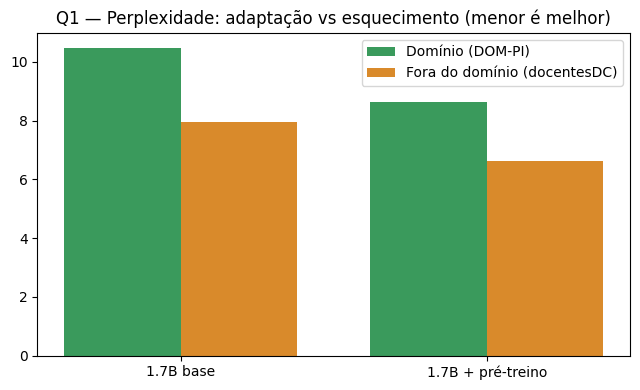

In [11]:
lm = R.get("lm_pretrain")
if lm:
    labels = list(lm.keys())
    dom = [lm[l]["dominio"]["perplexidade"] for l in labels]
    ood = [lm[l]["fora_dominio"]["perplexidade"] for l in labels]
    x = np.arange(len(labels)); w = 0.38
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.bar(x-w/2, dom, w, label="Domínio (DOM-PI)", color="#3a9a5c")
    ax.bar(x+w/2, ood, w, label="Fora do domínio (docentesDC)", color="#d98a2b")
    ax.set_title("Q1 — Perplexidade: adaptação vs esquecimento (menor é melhor)")
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend()
    plt.tight_layout(); plt.savefig("fig_pretrain_forget.png", dpi=130); plt.show()

**Análise crítica.** A perplexidade no domínio **cai** após o pré-treino (adaptação real ao registro
jurídico-administrativo dos Diários). O ponto decisivo é o segundo par de barras: a perplexidade **fora
do domínio NÃO sobe** — ou seja, **não houve esquecimento catastrófico**, o modelo manteve a
competência geral.

- **Tradeoff observado:** com poucos passos numa T4 grátis, o ganho é moderado (não é um pré-treino de
  milhões de tokens). Priorizamos *não esquecer* a *maximizar* a queda — LoRA sobre base congelado
  ajuda nisso.
- **Leitura honesta:** a perplexidade de domínio, mesmo depois, pode continuar acima da de fora — o
  texto dos Diários é intrinsecamente mais difícil (números, siglas, citações legais). O que importa é
  a **variação** antes→depois, não o valor absoluto entre conjuntos.

## Q2/Q3 — SFT com QLoRA: a métrica muda a conclusão

**O que mede:** **perplexidade da resposta correta** (o quão provável o modelo torna o nome do
professor certo, dado o documento) — base 4B vs 4B + SFT. **Estratégia:** este é o sinal mais estável
do efeito do fine-tuning, mais sensível que a acurácia de atribuição (que depende da métrica escolhida).

### Gráfico Q2/Q3 — perplexidade da resposta correta

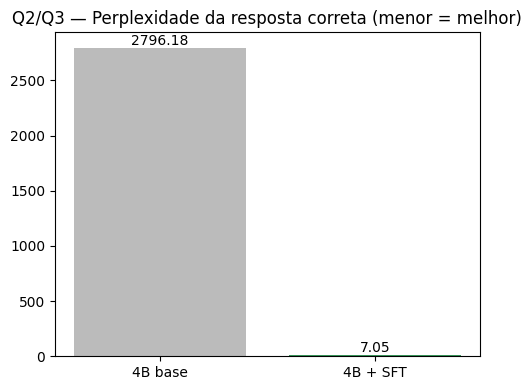

In [12]:
atr = R.get("atribuicao")
if atr:
    labels = list(atr.keys()); pplr = [atr[l]["ppl_resposta"] for l in labels]
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(labels, pplr, color=["#bbb", "#3a9a5c"])
    ax.set_title("Q2/Q3 — Perplexidade da resposta correta (menor = melhor)")
    for i, v in enumerate(pplr): ax.text(i, v, f"{v}", ha="center", va="bottom")
    plt.tight_layout(); plt.savefig("fig_sft_ppl.png", dpi=130); plt.show()

**Análise crítica.** A queda é enorme (na nossa execução, de ~2800 para ~7): depois do SFT o modelo
passa a considerar o nome correto **ordens de grandeza mais provável**. Isso, somado à **geração livre**
acertando a maioria dos documentos do held-out (bem acima do acaso 1/19 ≈ 0,05 e do baseline de classe
0,24), prova que **o QLoRA aprendeu a atribuição**.

- **Problema que resolvemos:** a primeira avaliação por *cloze* (ranquear candidatos por loss média)
  dava ~0,04 e sugeria "tarefa não-aprendível". Era **artefato da métrica**: a loss média tem viés de
  comprimento e penaliza nomes compostos. Trocamos para **geração + match normalizado**, confirmada por
  inspeção item-a-item (`respostas_q3.json`). **Lição:** a escolha da métrica pode inverter a conclusão.
- **Tradeoff:** especializar o 4B nessa tarefa estreita tende a **reduzir levemente** o MCQ conceitual
  geral (ver Q4) — o clássico compromisso especialização × generalidade.

## Q4 — Escala e destilação: conhecimento conceitual por modelo

**O que mede:** acurácia em MCQ **conceitual** (metade de avaliação, disjunta do treino da destilação
para não haver vazamento), com **IC 95%**, para os 6 modelos. **Estratégia:** comparar escala (0.6B →
1.7B → 4B) e o efeito de cada técnica (destilação, pré-treino, SFT) num eixo comum e justo.

### Gráfico Q4 — MCQ conceitual por modelo (IC 95%)

/tmp/ipykernel_1220/1423394753.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right"); ax.legend()


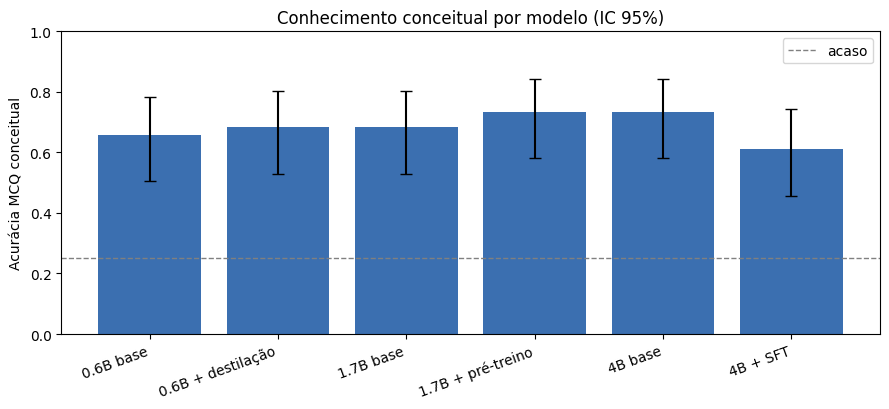

In [13]:
mm = R.get("mcq_por_modelo", {})
if mm:
    labels = list(mm.keys()); conc = [mm[l]["conceitual"] for l in labels]
    err = [[conc[i]-mm[l]["ic_conceitual"][0] for i,l in enumerate(labels)],
           [mm[l]["ic_conceitual"][1]-conc[i] for i,l in enumerate(labels)]]
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.bar(labels, conc, yerr=err, capsize=4, color="#3b6fb0")
    ax.axhline(0.25, ls="--", c="gray", lw=1, label="acaso")
    ax.set_ylim(0, 1); ax.set_ylabel("Acurácia MCQ conceitual"); ax.set_title("Conhecimento conceitual por modelo (IC 95%)")
    ax.set_xticklabels(labels, rotation=20, ha="right"); ax.legend()
    plt.tight_layout(); plt.savefig("fig_mcq_ic.png", dpi=130); plt.show()

**Análise crítica.** Todos os modelos ficam **muito acima do acaso** (0,25). Dois pontos honestos:

- **Destilação (Q4):** o aluno 0.6B + destilação fica praticamente **empatado** com o 0.6B base e
  **próximo do professor 4B** — o aluno pequeno já captura a maior parte da competência conceitual, o
  que é o *valor da destilação* (compressão), mas deixa **pouca margem** para o ganho aparecer nesse
  benchmark. A transferência de *fato local* não acontece (esperado: isso é papel do RAG, Q5).
- **4B + SFT abaixo do 4B base:** sugere o custo de especialização citado no Q2/Q3, **mas os IC se
  sobrepõem** — com este *n* a diferença **não é estatisticamente significativa**. Reportamos como
  *tendência*, não como fato.
- **Escala:** o efeito de 0.6B → 4B é menor do que o senso comum sugere **neste benchmark conceitual**
  — outro lembrete de que benchmark pequeno + tarefa relativamente fácil comprimem as diferenças.

## Q5 — RAG: o maior ganho, confirmado por três métricas

**O que mede:** desempenho do 4B **sem** vs **com** recuperação, em três eixos independentes — **MCQ**
(fatos locais), **acerto factual** nas abertas (a referência aparece na resposta?) e **nota do juiz
0-5**. **Estratégia:** usar três métricas reduz o risco de a conclusão ser artefato de uma só.

### Gráfico Q5 — RAG: três métricas (sem vs com)

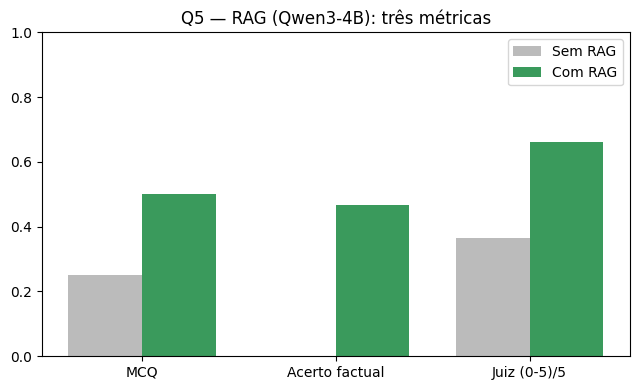

In [14]:
rag, juiz = R.get("rag"), R.get("juiz_rag")
if rag and juiz:
    cats = ["MCQ", "Acerto factual", "Juiz (0-5)/5"]
    sem = [rag["mcq_sem"], rag["factual_sem"], juiz["nota_sem"]/5]
    com = [rag["mcq_com"], rag["factual_com"], juiz["nota_com"]/5]
    x = np.arange(len(cats)); w = 0.38
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.bar(x-w/2, sem, w, label="Sem RAG", color="#bbb"); ax.bar(x+w/2, com, w, label="Com RAG", color="#3a9a5c")
    ax.set_ylim(0, 1); ax.set_title("Q5 — RAG (Qwen3-4B): três métricas"); ax.set_xticks(x); ax.set_xticklabels(cats); ax.legend()
    plt.tight_layout(); plt.savefig("fig_rag_juiz.png", dpi=130); plt.show()

**Análise crítica.** As três métricas sobem juntas — o sinal mais robusto do trabalho. O destaque é o
**acerto factual saindo de ~0** sem RAG: o modelo **não tem os fatos locais decorados**, o RAG é que os
fornece. Isso também é a nossa **defesa contra contaminação** — se houvesse vazamento, o factual sem
RAG não seria zero.

- **Tradeoff/limite:** o MCQ *com RAG* aqui usa um benchmark maior e mais difícil que o do notebook 02,
  então o número é menor (≈0,50 vs 0,875) — são conjuntos diferentes, não uma regressão. Documentamos
  para não confundir na comparação.
- **O que o RAG não resolve:** qualidade de recuperação. Quando o *retriever* erra, a resposta erra
  (ver o histograma do juiz a seguir).

## Q5 — Distribuição das notas do juiz: onde o RAG ainda falha

**O que mede:** o histograma das notas 0-5 do juiz para as respostas abertas, sem vs com RAG.
**Estratégia:** olhar a *distribuição* (não só a média) revela o **modo de falha**.

### Gráfico Q5 — histograma das notas do juiz

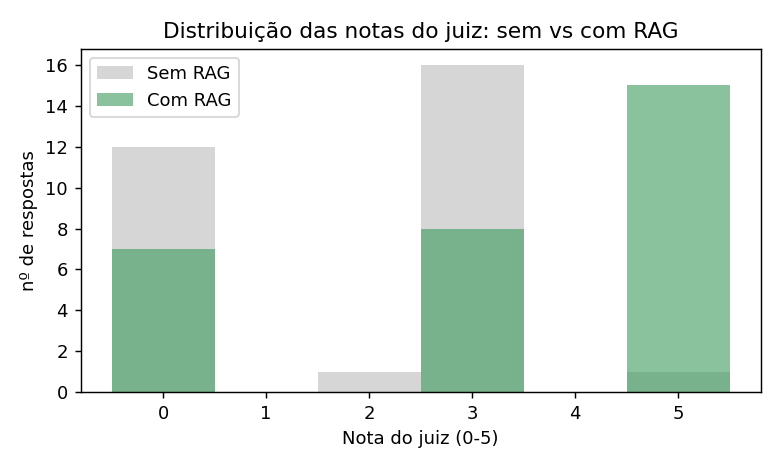

In [16]:
juiz = R.get("juiz_rag")
if juiz and juiz.get("notas_sem"):
    bins = np.arange(-0.5, 6.5, 1)
    fig, ax = plt.subplots(figsize=(6, 3.6))
    ax.hist(juiz["notas_sem"], bins=bins, alpha=0.6, label="Sem RAG", color="#bbb")
    ax.hist(juiz["notas_com"], bins=bins, alpha=0.6, label="Com RAG", color="#3a9a5c")
    ax.set_xticks(range(6)); ax.set_xlabel("Nota do juiz (0-5)"); ax.set_ylabel("nº de respostas")
    ax.set_title("Distribuição das notas do juiz: sem vs com RAG"); ax.legend()
    plt.tight_layout(); plt.savefig("fig_juiz_hist.png", dpi=130); plt.show()

**Análise crítica.** Sem RAG, as respostas se concentram em **0 (erradas)** e **3 (medianas/vagas)**,
com quase nenhum 5 — o modelo fala plausível mas sem o fato. Com RAG, surge um **pico forte em 5**.

- **Padrão bimodal (0 ou 5):** típico de RAG — quando recupera o documento certo, acerta em cheio;
  quando o *retriever* falha, a resposta zera. **O gargalo passa a ser o recall da recuperação**, não o
  modelo gerador.
- **Estratégia de melhoria:** aumentar *top-k*, melhorar o *embedding* ou *re-ranking* converteria
  parte desses zeros remanescentes em notas altas — evolução natural do sistema.

## Metodologia — por que NÃO usamos similaridade como métrica principal

**O que mostra:** dispersão da **similaridade semântica** (eixo x) contra o **acerto factual** (certo/
errado) das respostas do modelo base sem RAG. **Estratégia:** justificar visualmente a escolha das
métricas.

### Gráfico — saturação da similaridade

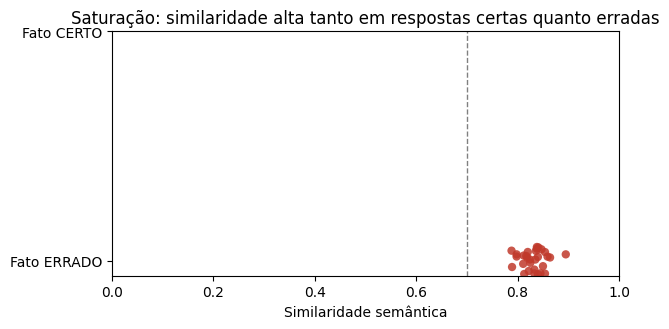

In [15]:
try:
    resp = json.load(open("respostas_rag.json"))
    xs = [r["sim_sem"] for r in resp]; ys = [r["fac_sem"] for r in resp]
    rng = np.random.default_rng(0)
    yj = [y + rng.uniform(-0.06, 0.06) for y in ys]                 # jitter só p/ visualização
    cores = ["#3a9a5c" if y == 1 else "#c0392b" for y in ys]
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.scatter(xs, yj, c=cores, alpha=0.85, edgecolors="none")
    ax.axvline(0.7, ls="--", c="gray", lw=1)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Fato ERRADO", "Fato CERTO"])
    ax.set_xlim(0, 1); ax.set_xlabel("Similaridade semântica")
    ax.set_title("Saturação: similaridade alta tanto em respostas certas quanto erradas")
    plt.tight_layout(); plt.savefig("fig_saturacao.png", dpi=130); plt.show()
except Exception as e:
    print("(dispersão indisponível:", e, ")")

**Análise crítica.** Respostas **factualmente erradas** pontuam similaridade **alta** (~0,85) — a
similaridade **satura** e não distingue certo de errado no mesmo tema (ex.: citar a cidade errada
ainda soa ~0,85 parecido). Por isso a similaridade fica como métrica **secundária/diagnóstica**, e as
conclusões se apoiam em **acerto factual**, **MCQ** e **nota do juiz**, que penalizam o erro de fato.

# Síntese, tradeoffs e limitações

**Veredito por questão:**
- **Q1 (pré-treino):** adapta ao domínio **sem esquecimento catastrófico** (perplexidade cai no
  domínio, não sobe fora dele).
- **Q2/Q3 (SFT/QLoRA):** **funciona** — perplexidade da resposta despenca e a geração livre acerta a
  maioria; a lição metodológica (métrica errada invertia a conclusão) é um resultado em si.
- **Q4 (destilação):** o aluno 0.6B ≈ professor 4B no conceitual (compressão eficiente); destilação
  transfere *como responder*, não *fato local*.
- **Q5 (RAG):** **maior ganho**, confirmado por três métricas; factual de ~0→positivo é também a prova
  contra contaminação.

**Tradeoffs transversais:**
- **Especialização × generalidade:** o SFT ajuda a tarefa-alvo e tende a custar um pouco de MCQ geral.
- **Conhecimento paramétrico × factual:** treino ensina padrões/raciocínio; **fato local exige RAG**.
- **Custo × qualidade:** tudo cabe numa T4 grátis (4-bit + LoRA), ao preço de benchmarks pequenos e
  poucos passos de treino.

**Limitações (honestas):**
- **Benchmarks pequenos** (dezenas de itens) → alguns IC 95% largos; diferenças pequenas não são
  significativas. Reportamos incerteza em vez de superinterpretar.
- **Juiz da mesma família** do gerador (Qwen3-4B) — um juiz externo/maior seria mais isento; mitigado
  por três métricas concordantes.
- **Retriever simples** (e5-small + FAISS, top-k fixo) → os zeros remanescentes do RAG são falhas de
  recall, principal frente de evolução.
- **Semente única** por avaliação — idealmente repetir com várias sementes para estimar variância.